# Imports and Setup


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


import numpy as np
import pandas as pd

import seaborn as sns
import torch

import re
from itertools import product
sns.set_style("whitegrid")
DPI= 1000


## Helpers


# Reach No Obs

## Static Tasks

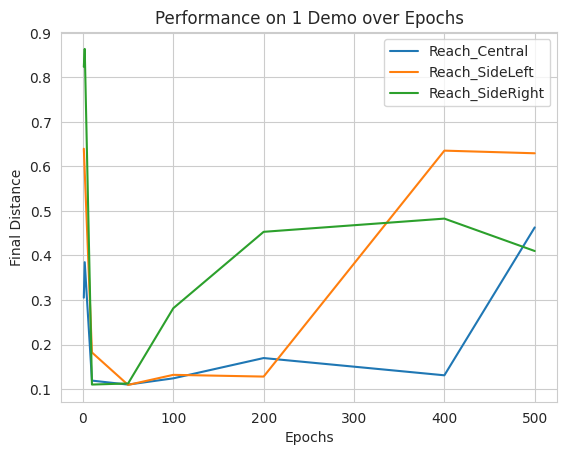

In [47]:
df = pd.read_csv("report-data/reach-no-obs/rno_static.csv")

## remove epochs greated than 10,000 dont really need them
df = df[df["epochs"] <= 500]

obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]

sns.lineplot(data = obs_df, x="epochs", y="final_distance", hue="task_name", errorbar="sd", palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Performance on 1 Demo over Epochs")
plt.legend()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_static.png", format="png", dpi=DPI)
plt.show()


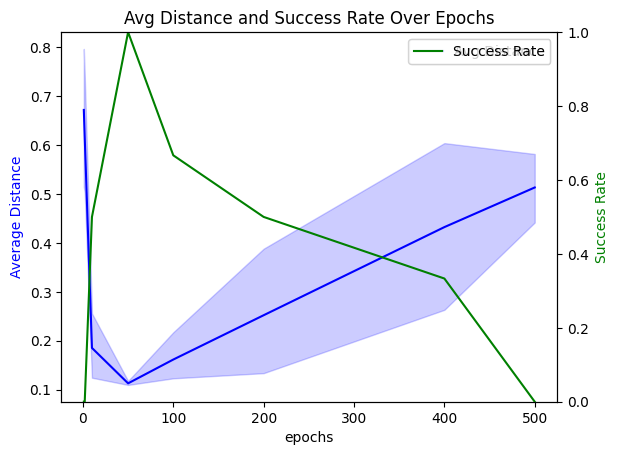

In [22]:
success_rate = df.groupby('epochs')['is_success'].mean().reset_index()

fig, ax1 = plt.subplots()

# Plot average distance
sns.lineplot(data=df, x='epochs', y='final_distance', ax=ax1, label='Avg Distance', color='blue')
ax1.set_ylabel('Average Distance', color='blue')

# Plot success rate on secondary axis
ax2 = ax1.twinx()
sns.lineplot(data=success_rate, x='epochs', y='is_success', ax=ax2, label='Success Rate', color='green')
ax2.set_ylabel('Success Rate', color='green')
ax2.set_ylim(0, 1)

plt.title('Avg Distance and Success Rate Over Epochs')
plt.show()

## Place Random

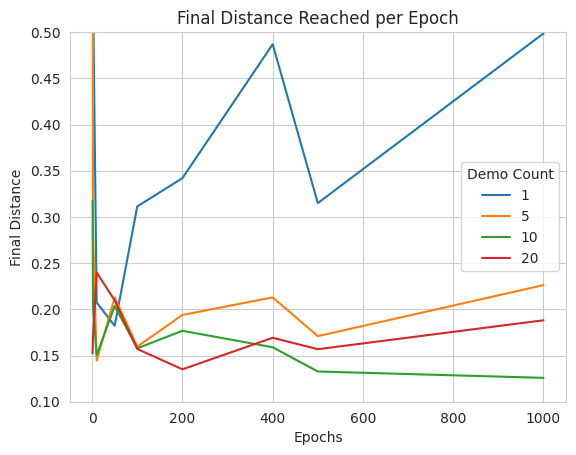

In [36]:
df = pd.read_csv("report-data/reach-no-obs/rno-place_random.csv")

## using only obs as this is a part of the timeline, ran all jsut in case
obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]

# sns.lineplot(data = demo_df, x="epochs", y="final_distance", hue="demo_count", errorbar="sd", palette="tab10")
# plt.xlabel("Epochs")
# plt.ylabel("Final Distance")
# plt.title("Final Distance Reached per Epoch (DEMO)")
# plt.legend()
# # plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-dist.png", format="png", dpi=500)
# plt.show()
sns.lineplot(data = obs_df, x="epochs", y="final_distance", hue="demo_count", errorbar="sd", palette="tab10")
# sns.lineplot(data = demo_df, x="epochs", y="final_distance", errorbar="sd", label="Demo dataset")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.ylim(0.1, 0.50)
plt.title("Final Distance Reached per Epoch")
plt.legend(title="Demo Count")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-dist.png", format="png", dpi=DPI)
plt.show()


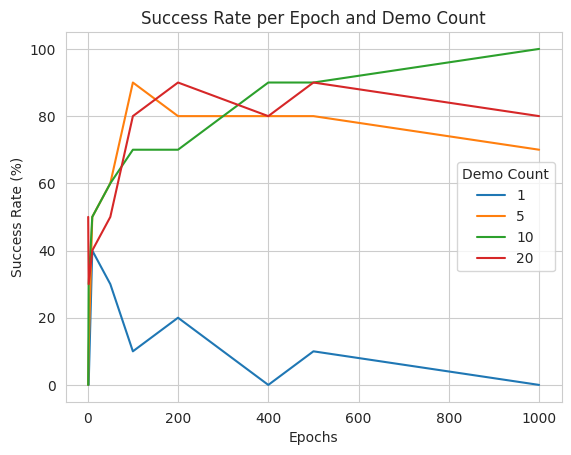

In [37]:
df = pd.read_csv("report-data/reach-no-obs/rno-place_random.csv")
df["success"] = df["done_count"].apply(lambda dc: 100 *  dc / 10)
## remove epochs greated than 10,000 dont really need them

obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]

sns.lineplot(data = obs_df, x="epochs", y="success", hue="demo_count", errorbar="sd", palette="tab10")
plt.ylabel("Success Rate (%)")
plt.xlabel("Epochs")
plt.title("Success Rate per Epoch and Demo Count")
plt.legend(title="Demo Count")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-success.png", format="png", dpi=DPI)
plt.show()






## Different Cameras

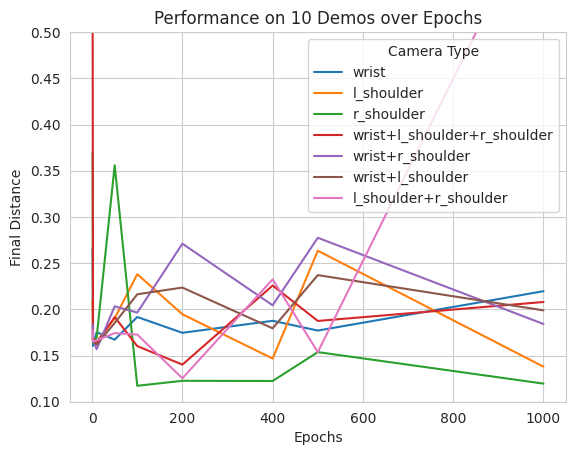

In [48]:
df = pd.read_csv("report-data/reach-no-obs/place_random-cam.csv")

## remove epochs greated than 10,000 dont really need them
# df = df[df["epochs"] <= 500]
obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]

sns.lineplot(data = obs_df, x="epochs", y="final_distance", hue="cam_type", errorbar="sd", palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.ylim(0.1, 0.50)
plt.title("Performance on 10 Demos over Epochs")
plt.legend(title="Camera Type")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-cams.png", format="png", dpi=DPI)
plt.show()


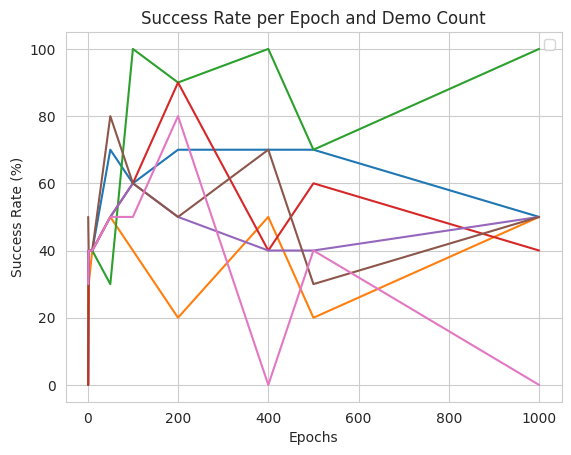

In [49]:
df["success"] = df["done_count"].apply(lambda dc: 100 *  dc / 10)
## remove epochs greated than 10,000 dont really need them

obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]

sns.lineplot(data = obs_df, x="epochs", y="success", hue="cam_type", errorbar="sd", palette="tab10")
plt.ylabel("Success Rate (%)")
plt.xlabel("Epochs")
plt.title("Success Rate per Epoch and Demo Count")
plt.legend("")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-cam_success.png", format="png", dpi=DPI)
plt.show()


# Reach Obs

## MultiCam Reach


In [3]:
df = pd.read_csv("report-data/reach-obs/multicam/ro-randoms-cam.csv")
df["success_pct"] = df["done_count"].apply(lambda c: 10 * c)

obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]


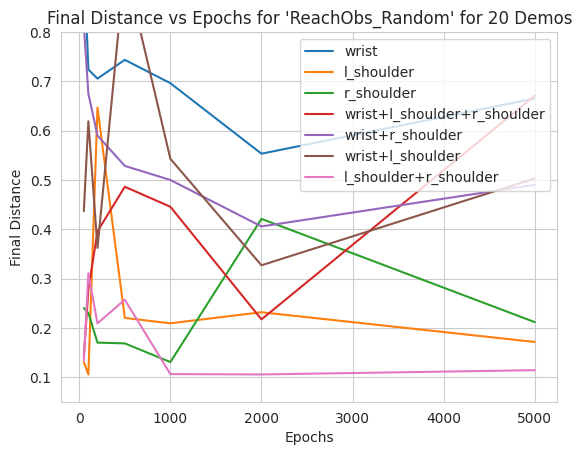

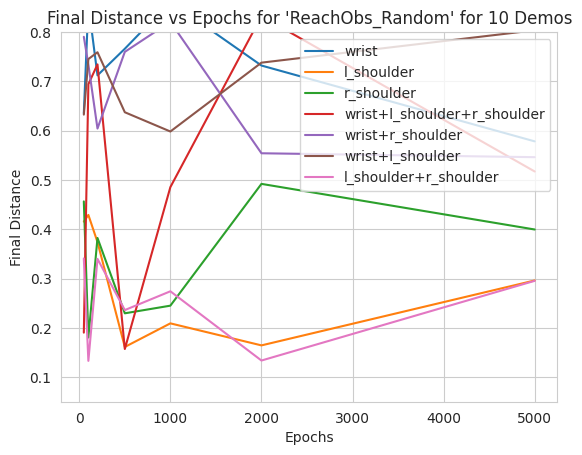

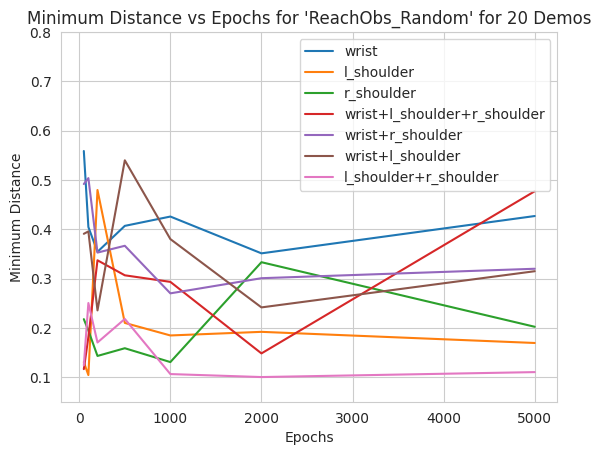

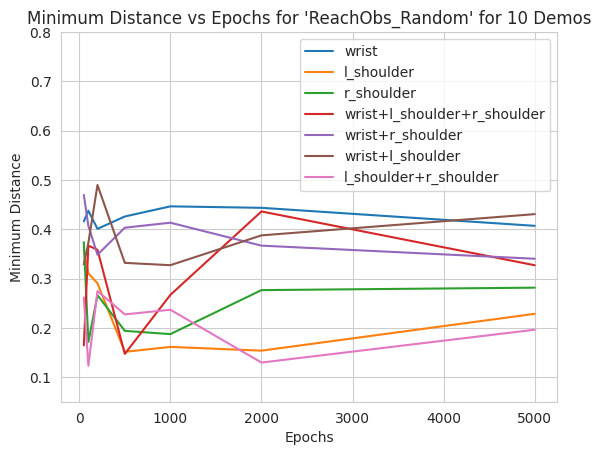

In [14]:
obs_rand = obs_df[obs_df["task_name"] == "ReachObs_Random"]
obs_ind = obs_df[obs_df["task_name"] == "ReachObs_IndRandom"]
# plt.figure(figsize=fs)
obs_rand20 = obs_rand[obs_rand["demo_count"] == 20]
obs_rand10 = obs_rand[obs_rand["demo_count"] == 10]

obs_ind20 = obs_ind[obs_ind["demo_count"] == 20]
obs_ind10 = obs_ind[obs_ind["demo_count"] == 10]

sns.lineplot(data = obs_rand20, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-dist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = obs_rand10, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-dist-10demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = obs_rand20, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-mindist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = obs_rand10, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-mindist-10demos.png", format="png", dpi=DPI)
plt.show()






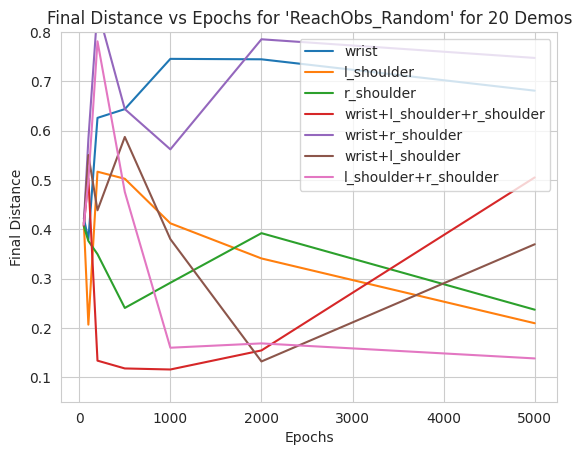

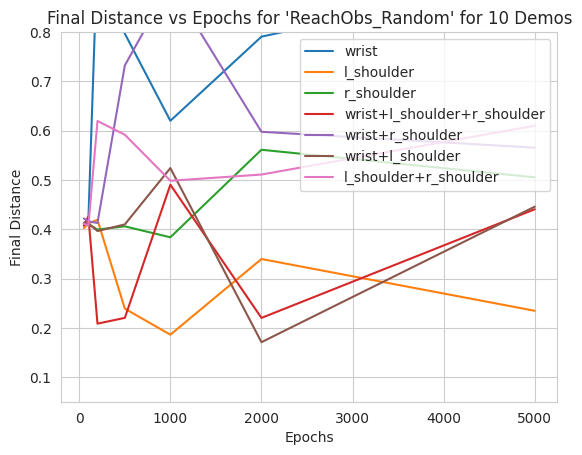

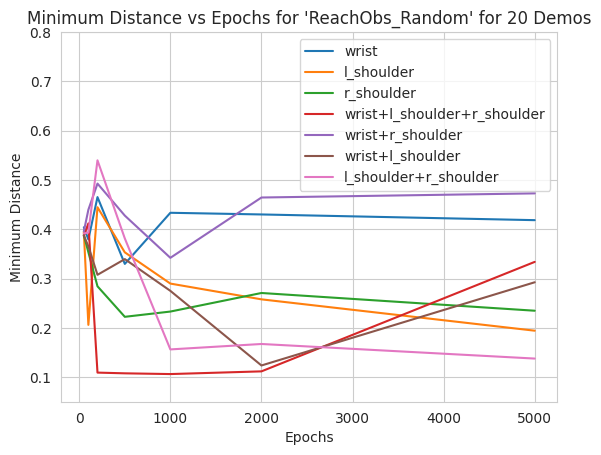

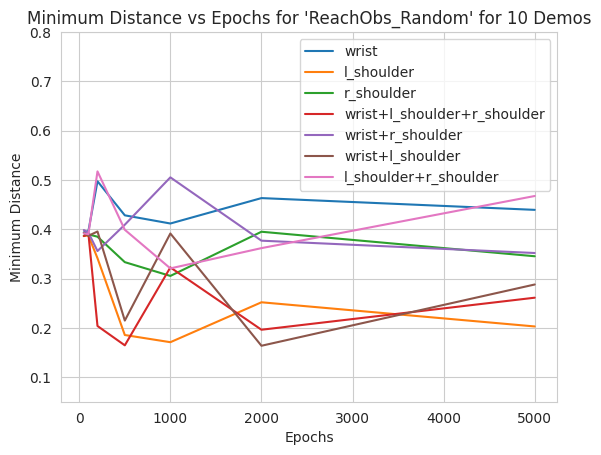

In [13]:
demo_rand = demo_df[demo_df["task_name"] == "ReachObs_Random"]
demo_ind = demo_df[demo_df["task_name"] == "ReachObs_IndRandom"]

demo_rand20 = demo_rand[demo_rand["demo_count"] == 20]
demo_rand10 = demo_rand[demo_rand["demo_count"] == 10]

demo_ind20 = demo_ind[demo_ind["demo_count"] == 20]
demo_ind10 = demo_ind[demo_ind["demo_count"] == 10]

sns.lineplot(data = demo_rand20, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-dist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = demo_rand10, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-dist-10demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = demo_rand20, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-mindist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = demo_rand10, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-mindist-10demos.png", format="png", dpi=DPI)
plt.show()

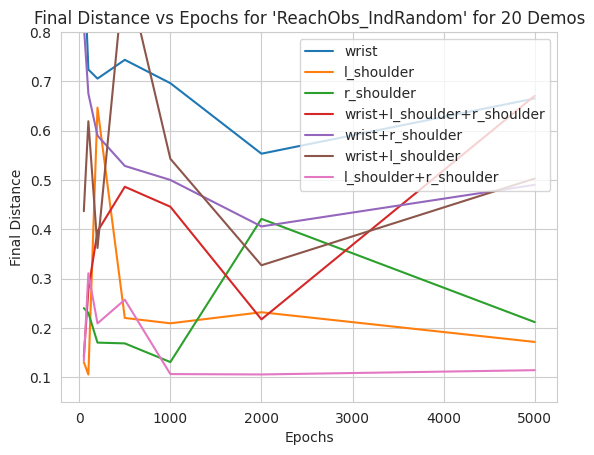

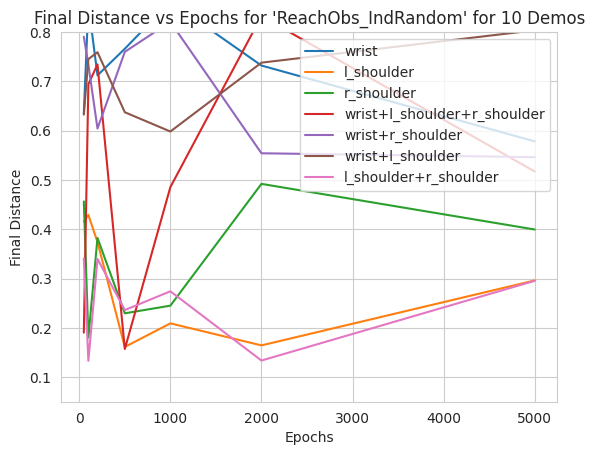

In [5]:
sns.lineplot(data = obs_rand20, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_IndRandom' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-dist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = obs_rand10, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_IndRandom' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-dist-10demos.png", format="png", dpi=DPI)
plt.show()

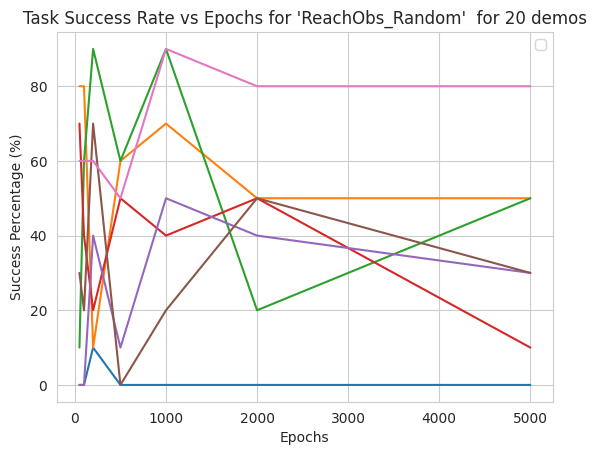

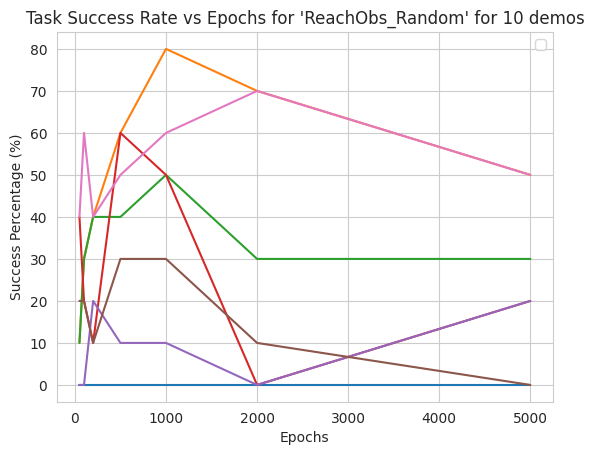

In [131]:
# g = sns.catplot(
#   data = obs_df, 
#   y = "success_pct", 
#   x = "epochs",
#   hue = "cam_type",
#   row ="task_name",
#   kind="bar",
#   errorbar=None,
#   height=4,
#   aspect=1.3
# )
# g.set_titles("Task Name : {row_name}")
# g.set_axis_labels("Epochs", "Success Rate (%)")
# g.tight_layout()
# g.figure.suptitle("Task Success per Task and Epochs")
# plt.subplots_adjust(top=0.9)
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-success.png", format="png", dpi=DPI)
# plt.show()
sns.lineplot(data = obs_rand20, x="epochs", y="success_pct", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Percentage (%)")
plt.title("Task Success Rate vs Epochs for 'ReachObs_Random'  for 20 demos")
# plt.ylim(0.05, 0.8)
# plt.legend(loc="lower right")
plt.legend("")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-success-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = obs_rand10, x="epochs", y="success_pct", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Percentage (%)")
plt.title("Task Success Rate vs Epochs for 'ReachObs_Random' for 10 demos")
# plt.ylim(0.05, 0.8)
# plt.legend(loc="lower right")
plt.legend("")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-success-10demos.png", format="png", dpi=DPI)
plt.show()




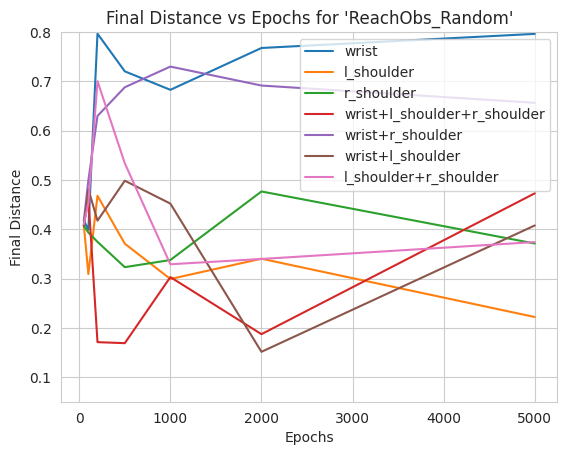

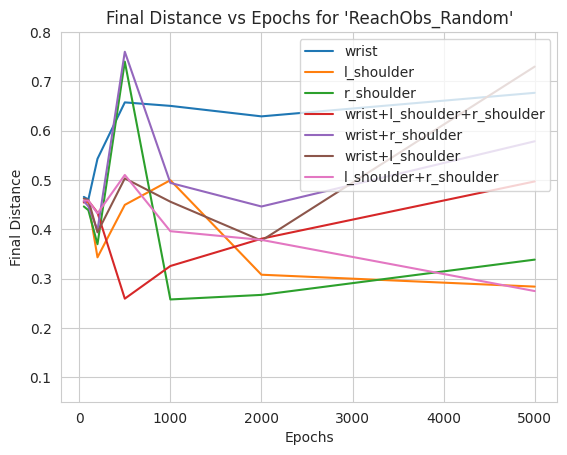

In [ ]:
obs_rand = demo_df[demo_df["task_name"] == "ReachObs_Random"]
obs_ind = demo_df[demo_df["task_name"] == "ReachObs_IndRandom"]
# plt.figure(figsize=fs)
sns.lineplot(data = obs_rand, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random'")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.show()

# plt.figure(figsize=fs)
sns.lineplot(data = obs_ind, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' ")
plt.legend(loc="upper right")
plt.ylim(0.05, 0.8)
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_static.png", format="png", dpi=DPI)
plt.show()

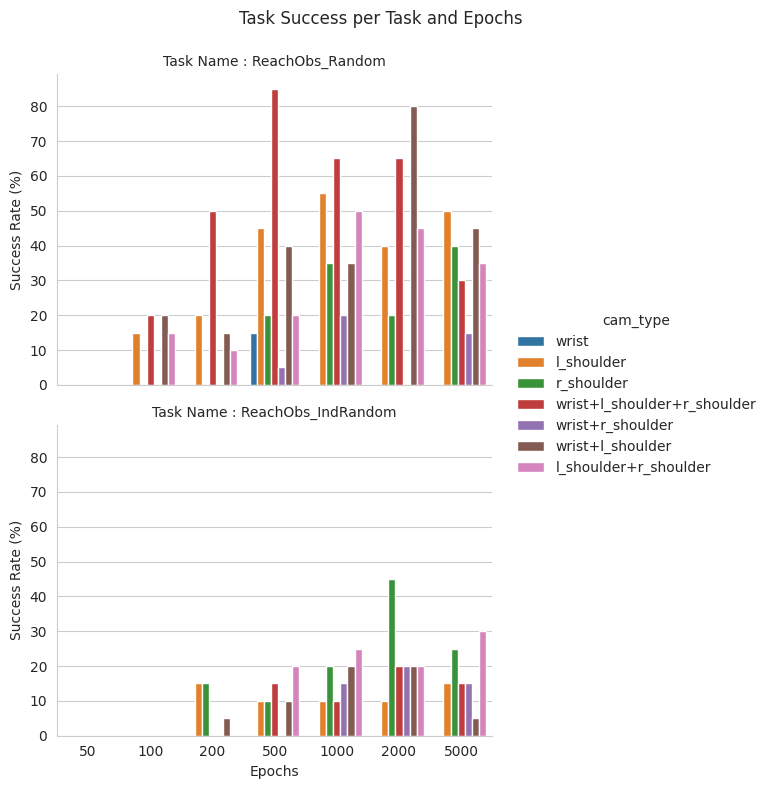

In [132]:
g = sns.catplot(
  data = demo_df, 
  y = "success_pct", 
  x = "epochs",
  hue = "cam_type",
  row ="task_name",
  kind="bar",
  errorbar=None,
  height=4,
  aspect=1.3
)
g.set_titles("Task Name : {row_name}")
g.set_axis_labels("Epochs", "Success Rate (%)")
g.tight_layout()
g.figure.suptitle("Task Success per Task and Epochs")
plt.subplots_adjust(top=0.9)



"obs" dataset performs better at thsi task and is generally more successful at crossing the obstacle
- this i hypothesise is because here it was trained with mbsize = 32, which is around half the demo episode length (around 82 here) I think what this achieves is that the robot (by chance) learns the two parts of the movement in tandem, so for every epoch before the loss is updated the robot will see 
(mention in presentation definitely one of the nice things i might have found out)

do a run with exactly half of max  eplen to check if this improves it?

while "demo" is updated demowise so mbsize = 1 (demo), this means that the loss is updated after each demo, which makes the robot learn a middleground optimal way to just bonk on the obstacle most of the time, and clearly fails to cross the obstacle as often as obs does

## Multicam Reach - Demo Dataset with mbsize: 10
all data is using the "demo" dataset, will also run a varying minibatch search later at night


In [9]:
df = pd.read_csv("report-data/reach-obs/multicam/demo-rerun-mbsize:10--ro-randoms-cam.csv")
df["success_pct"] = df["done_count"].apply(lambda c: 10 * c)

df_rand = df[df["task_name"] == "ReachObs_Random"]
df_ind = df[df["task_name"] == "ReachObs_IndRandom"]

df_rand10 = df_rand[df_rand["demo_count"] == 10]
df_rand20 = df_rand[df_rand["demo_count"] == 20]

df_ind10 = df_ind[df_ind["demo_count"] == 10]
df_ind20 = df_ind[df_ind["demo_count"] == 20]

### ReachObs_Random

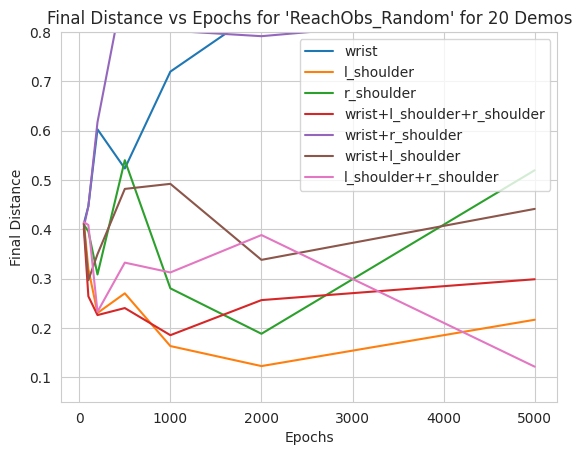

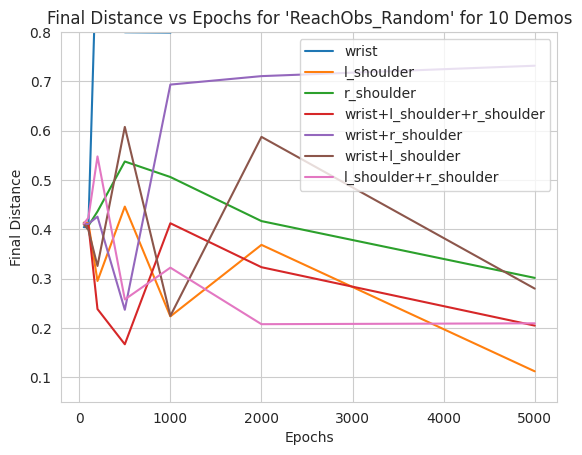

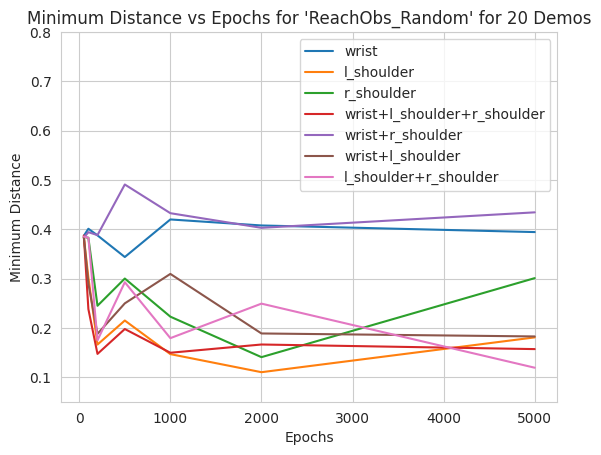

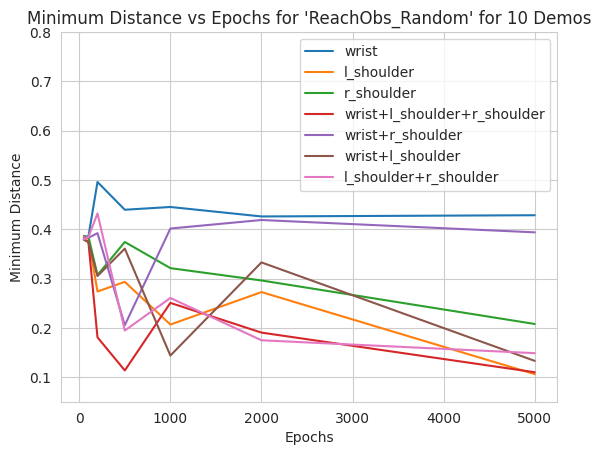

In [10]:
sns.lineplot(data=df_rand20, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-dist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_rand10, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-dist-10demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_rand20, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-mindist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_rand10, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-mindist-10demos.png", format="png", dpi=DPI)
plt.show()

### ReachObs_IndRandom


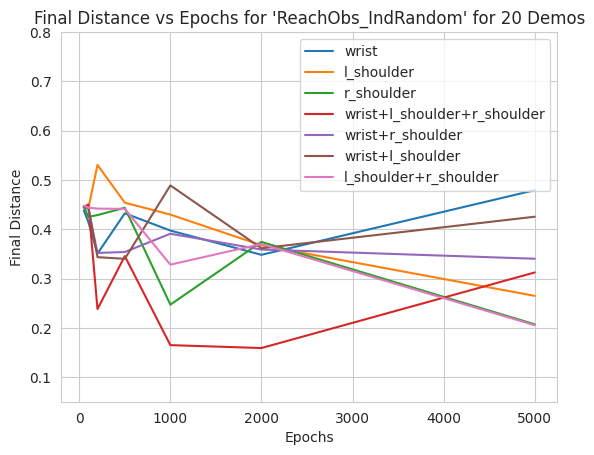

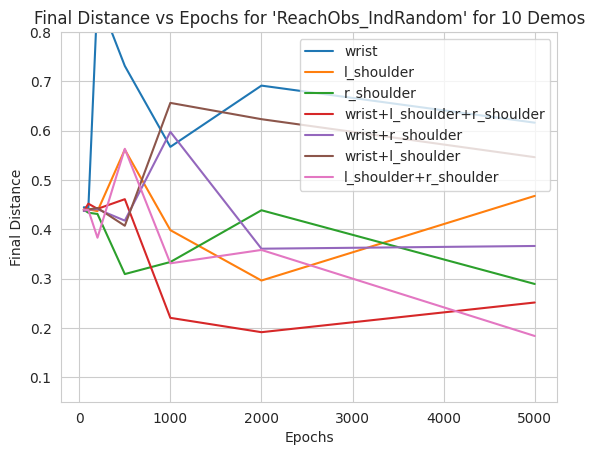

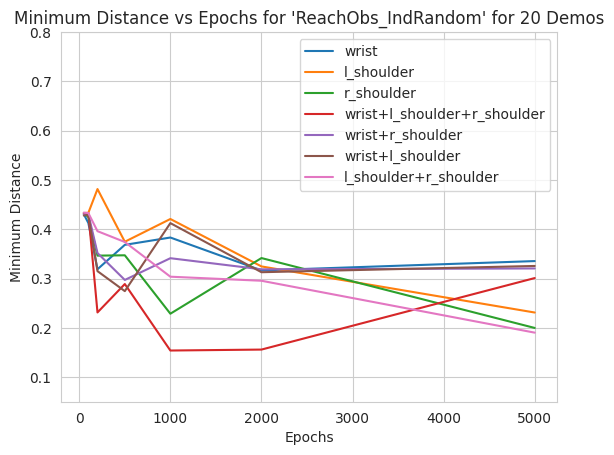

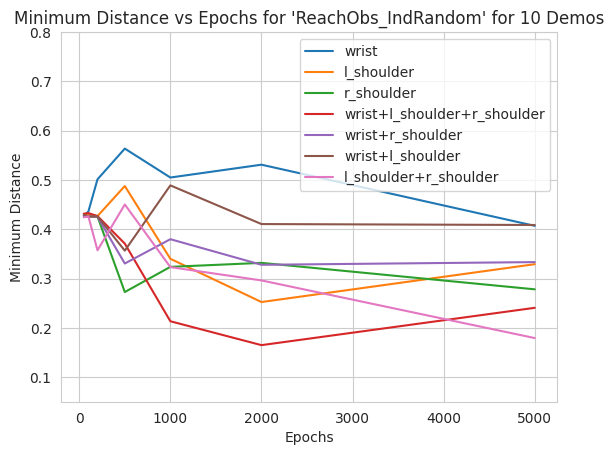

In [9]:
sns.lineplot(data=df_ind20, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_IndRandom' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-demo-dist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_ind10, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_IndRandom' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-demo-dist-10demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_ind20, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_IndRandom' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-demo-mindist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_ind10, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_IndRandom' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-demo-mindist-10demos.png", format="png", dpi=DPI)
plt.show()

# Depth Interfacing

## Vision Static
the plots from the vs is not the best currently, will first tune then actually run the tests again


### Tuning
Getting some good networks which I can then later use in Depth Interfacing

#### More linear layers

In [57]:
df_all = pd.read_csv("report-data/vision/vision-static/ALLvs-tuning-normal.csv")
df = pd.read_csv("report-data/vision/vision-static/vs-tuning-normal.csv")

no_depth_df = df[~df["cam_type"].str.contains("depth")]
no_depth_df_all = df_all[~df_all["cam_type"].str.contains("depth")]

In [ ]:
# Plot
g = sns.catplot(
    data=no_depth_df_all,
    x='grasp_loss_lambda',
    y='final_distance',
    hue='cam_type',
    col='epochs',
    kind='box',
    col_wrap=2,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Epochs: {col_name}")
g.set_axis_labels("lambda_g", "Final Distance")
g.set(ylim=(0.05, 0.3))
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")


In [ ]:
# Plot
g = sns.catplot(
    data=no_depth_df,
    x='grasp_loss_lambda',
    y='done_count',
    hue='cam_type',
    col='epochs',
    kind='bar',
    col_wrap=2,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Epochs: {col_name}")
g.set_axis_labels("lambda_g", "Final Distance")
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")

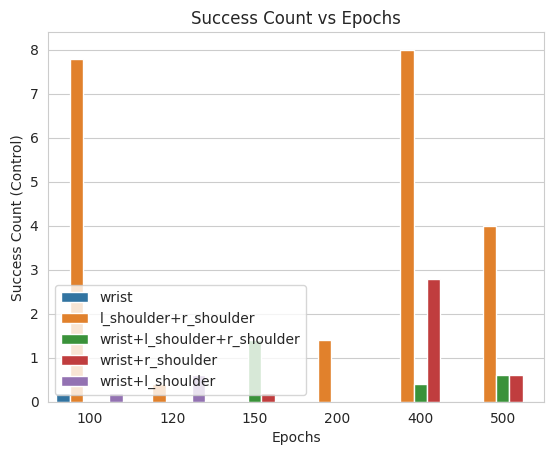

In [ ]:
sns.barplot(data=no_depth_df, x="epochs", y="done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Count (Control)")
plt.title("Success Count vs Epochs")
plt.legend(loc="lower left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

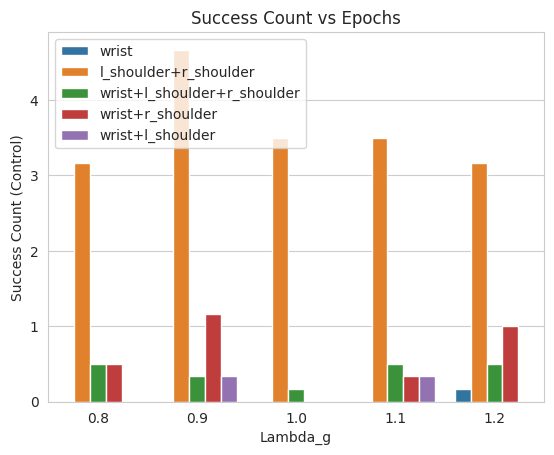

In [64]:
sns.barplot(data=no_depth_df, x="grasp_loss_lambda", y="done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Lambda_g")
plt.ylabel("Success Count (Control)")
plt.title("Success Count vs Epochs")
plt.legend(loc="upper left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

wrist does not learn well, likely due to there only being one demonstration, this means that there are very 

#### Tuning with the old policy, less linear layers for grasp in `grasp_head`

interesting result here for l shoulder + rshoulder 400 epochs, when it cant see it randomly grasps, which makes sense maybe put this in the report


Using the slightly less deep policy seems to perform the best, feat -> 128 -> 64 -> 1 rather than feat -> 128 -> 64 -> 32 -> 1

Reasons for this i shall understand soon enough

In [65]:
df_all = pd.read_csv("report-data/vision/vision-static/ALLvs-tuning-normal--old-policy.csv")
df = pd.read_csv("report-data/vision/vision-static/vs-tuning-normal--old-policy.csv")

no_depth_df = df[~df["cam_type"].str.contains("depth")]
no_depth_df_all = df_all[~df_all["cam_type"].str.contains("depth")]

Text(0.5, 0.98, 'Success Rate per Demo Type and Agent (per seeded Run)')

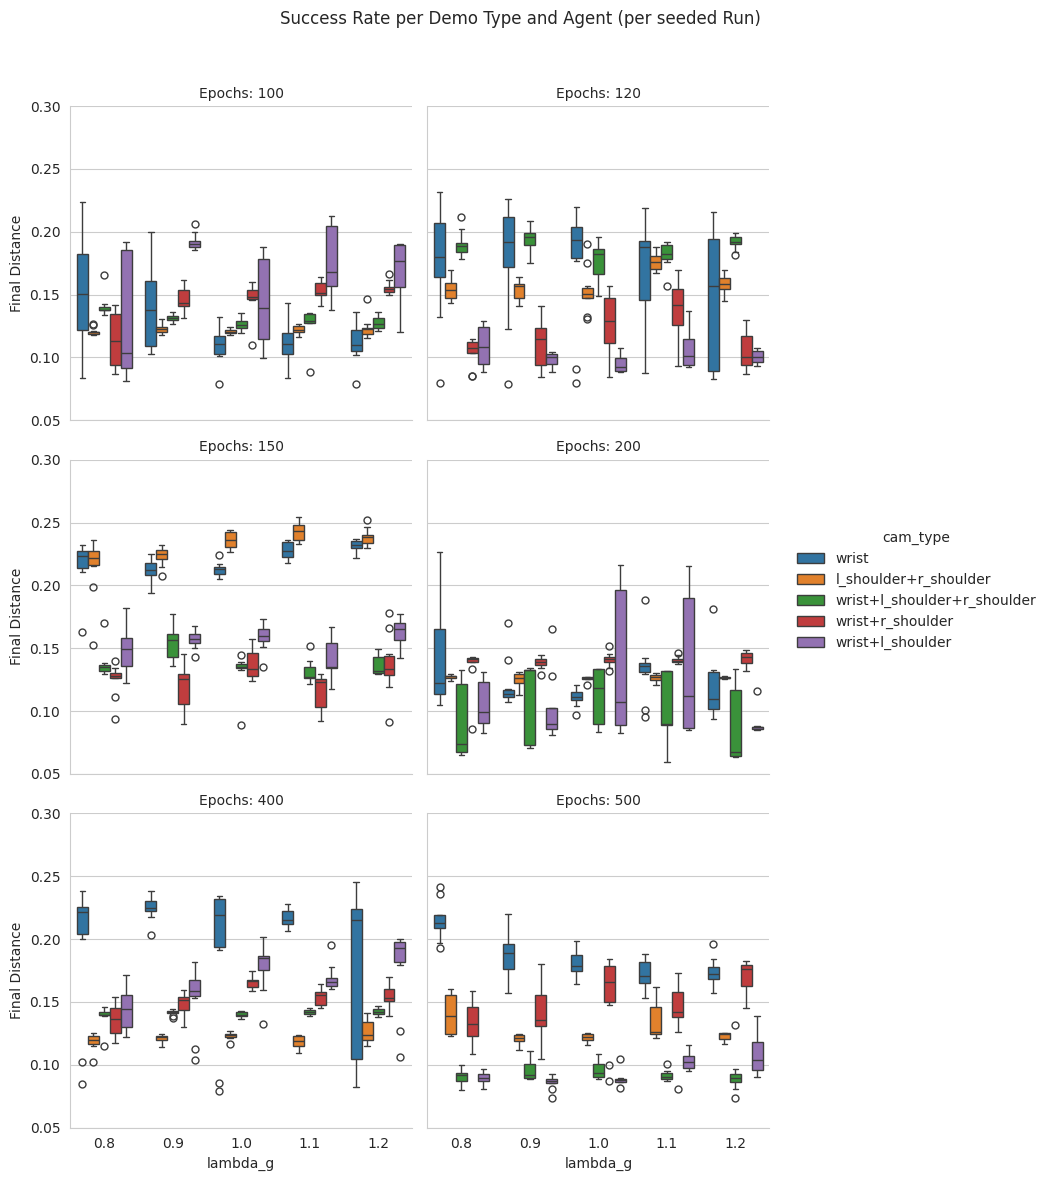

In [66]:
# Plot
g = sns.catplot(
    data=no_depth_df_all,
    x='grasp_loss_lambda',
    y='final_distance',
    hue='cam_type',
    col='epochs',
    kind='box',
    col_wrap=2,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Epochs: {col_name}")
g.set_axis_labels("lambda_g", "Final Distance")
g.set(ylim=(0.05, 0.3))
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")


Text(0.5, 0.98, 'Success Rate per Demo Type and Agent (per seeded Run)')

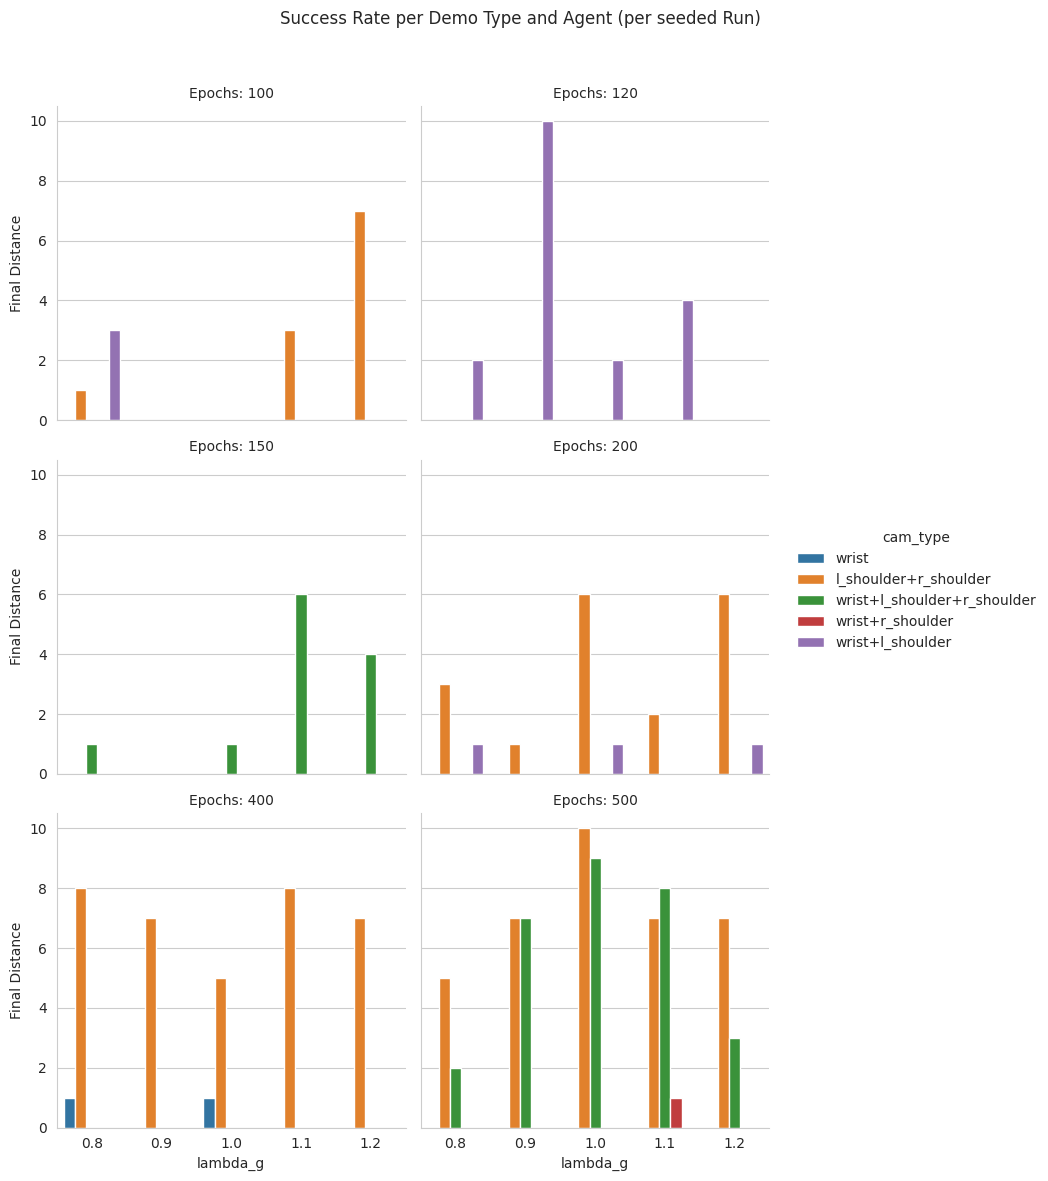

In [67]:
# Plot
g = sns.catplot(
    data=no_depth_df,
    x='grasp_loss_lambda',
    y='done_count',
    hue='cam_type',
    col='epochs',
    kind='bar',
    col_wrap=2,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Epochs: {col_name}")
g.set_axis_labels("lambda_g", "Final Distance")
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")

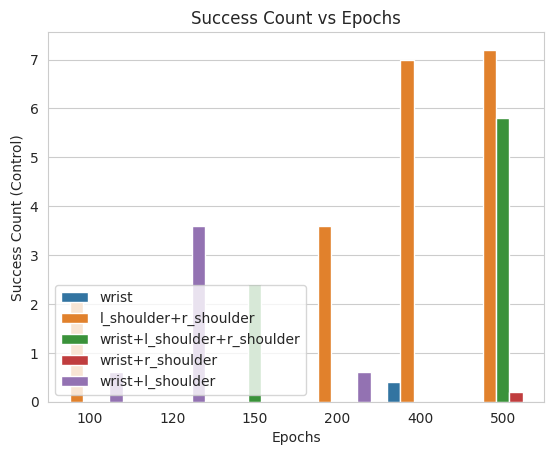

In [68]:
sns.barplot(data=no_depth_df, x="epochs", y="done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Count (Control)")
plt.title("Success Count vs Epochs")
plt.legend(loc="lower left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

### Normal and Small size performance comparison

there is a few versions of this, however dont want to run for many epochs will run reach obs tonight will see what I can do with this tmr night

In [51]:
full_df = pd.read_csv("report-data/vision/vision-static/vs-train_normal-test_small.csv")
df = full_df[~full_df["cam_type"].str.contains("depth")]

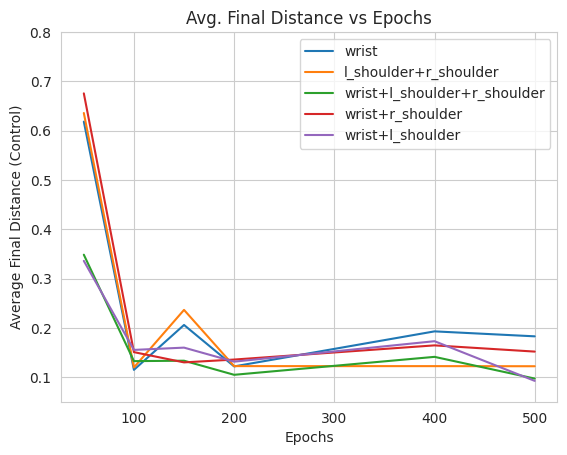

In [52]:
sns.lineplot(data=df, x="epochs", y="control_final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Average Final Distance (Control)")
plt.title("Avg. Final Distance vs Epochs")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

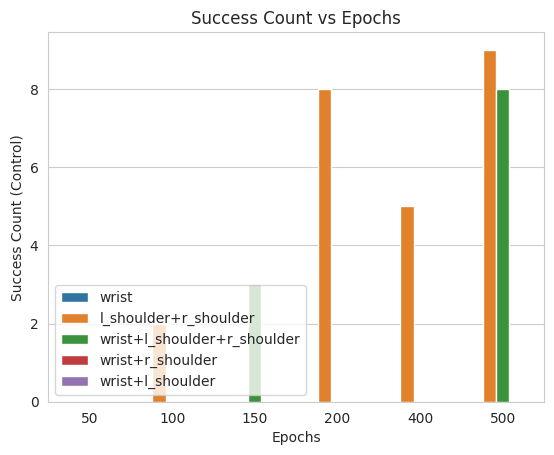

In [56]:
sns.barplot(data=df, x="epochs", y="control_done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Count (Control)")
plt.title("Success Count vs Epochs")
plt.legend(loc="lower left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

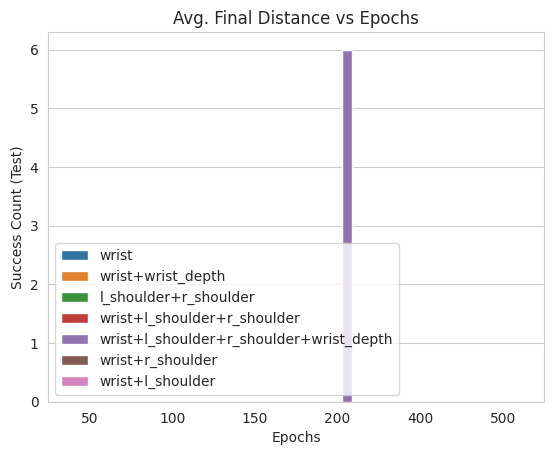

In [55]:
sns.barplot(data=full_df, x="epochs", y="test_done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Count (Test)")
plt.title("Avg. Final Distance vs Epochs")
plt.legend(loc="lower left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

# Next Section
